In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt



In [3]:
from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix     
print("All imports successful")

All imports successful


In [4]:
#loading the dataset and printing the description and head
df  = load_breast_cancer()
x = pd.DataFrame(df.data, columns=df.feature_names)
y = df.target
print(df.DESCR)


.. _breast_cancer_dataset:

Breast cancer Wisconsin (diagnostic) dataset
--------------------------------------------

**Data Set Characteristics:**

:Number of Instances: 569

:Number of Attributes: 30 numeric, predictive attributes and the class

:Attribute Information:
    - radius (mean of distances from center to points on the perimeter)
    - texture (standard deviation of gray-scale values)
    - perimeter
    - area
    - smoothness (local variation in radius lengths)
    - compactness (perimeter^2 / area - 1.0)
    - concavity (severity of concave portions of the contour)
    - concave points (number of concave portions of the contour)
    - symmetry
    - fractal dimension ("coastline approximation" - 1)

    The mean, standard error, and "worst" or largest (mean of the three
    worst/largest values) of these features were computed for each image,
    resulting in 30 features.  For instance, field 0 is Mean Radius, field
    10 is Radius SE, field 20 is Worst Radius.

    - 

In [5]:
#train test split
x_train, x_test , y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=42
)

In [6]:
#definning trainnig sizes to check for overfitting
train_sizes = np.linspace(0.1, 1.0, 10)
"""1st model will train on 10% of the data, 2nd model on 20% of the data and so on until the 10th model which will train on 100% of the data"""

'1st model will train on 10% of the data, 2nd model on 20% of the data and so on until the 10th model which will train on 100% of the data'

In [15]:
#initialising empty list to store train scores and test scores
train_scores = []
test_scores = []

#main loop
for frac in train_sizes:

    n_samples = int(len(x_train) * frac)

    x_subset = x_train.iloc[:n_samples]
    y_subset = y_train[:n_samples]

    #traning the model on the subset of the data
    model = RandomForestClassifier(random_state=42,
                                   n_estimators=1000,
                                      max_depth=3
                                   )
    model.fit(x_subset, y_subset)

    #eval
    train_pred = model.predict(x_subset)
    test_pred = model.predict(x_test)

    train_accuracy = accuracy_score(y_subset, train_pred)
    test_accuracy = accuracy_score(y_test, test_pred)   

    #storing the scores
    train_scores.append(train_accuracy)
    test_scores.append(test_accuracy)


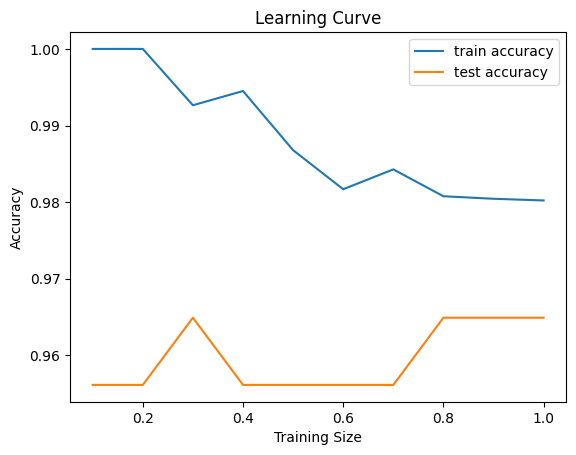


 final train accuracy : 0.9802
final test accuracy : 0.9649
overfitting gap : rounded 0.0153
model may be underfitted or well regularized


In [16]:

    #plotting the learning curve
plt.figure()
plt.plot(train_sizes, train_scores, label = 'train accuracy')
plt.plot(train_sizes, test_scores, label = 'test accuracy')
plt.xlabel('Training Size')
plt.ylabel('Accuracy')
plt.title('Learning Curve')
plt.legend()
plt.show()

    #overfitting detection
gap = train_scores[-1] - test_scores[-1]
print(f"\n final train accuracy : {train_scores[-1]:.4f}")
print(f"final test accuracy : {test_scores[-1]:.4f}")
print(f"overfitting gap : rounded {gap:.4f}")

if gap > 0.1:
    print("The model is overfitting")
elif gap < 0.02:
    print("model may be underfitted or well regularized")

else:
    print("model is generalizing well")
    